Con riferimento al data set dell’esercitazione su clustering, eseguire una classificazione 
binaria sulla feature death, una classificazione multiclasse sulla feature dzgroup ed una 
regressione sulla feature aps. 
Di seguito si riportano i passi da seguire separatamente per ciascun task: 
1. Procedere allo split train-test secondo il rapporto 95%-15% in forma stratificata 
secondo i valori della variabile target. 
2. Eseguire l’imputazione dei dati mancanti con le stesse strategie dell’esercitazione 
precedente. 
3. Rimuovere le feature che presentano elevata correlazione con la variabile target e 
successivamente analizzare le possibili feature multicollineari rimanenti. 
4. Utilizzare RandomForestClassifier per la classificazione e RandomForestRegressor per 
la regressione con i seguenti iperparametri(*) 
a. Classificatore 
i. criterion: “gini”, “log_loss” 
ii. min_samples_split: 2, 5, 10 
iii. max_features: “sqrt”, 5 
b. Regressore 
i. criterion: “squared_error”, “absolute_error” 
ii. min_samples_split: 2, 5, 10 
iii. max_features: “sqrt”, 5 
5. Valutare il regressore sul test set con la metrica R2, il classificatore binario con la curva 
ROC e la relativa AUC ed il classificatore multiclasse con le curve ROC e le AUC di ogni 
classe, ciascuna valutata in modalità one-vs-rest. 
(*) Si noti che gli iperparametri indicati potrebbero non essere quelli ottimali perché il 
modello di addestri bene. Opzionalmente si discuta se non sia il caso di condizionare il 
modello ad altri iperparametri e si conducano le relative prove.

In [15]:
#import dataset
import pandas as pd

df =  pd.read_csv('./dataset_esercitazione.csv')
print(df.shape)

(9105, 43)


In [16]:
#split-dataset

from sklearn.model_selection import train_test_split

df = df.dropna(subset=['aps'])
X = df.drop('aps', axis=1)
y = df['aps']

print(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



0       20.0
1       74.0
2       45.0
3       19.0
4       30.0
        ... 
9100    22.0
9101    31.0
9102    39.0
9103    51.0
9104     7.0
Name: aps, Length: 9104, dtype: float64


In [17]:
numeric_features = X_train.select_dtypes(include=['number']).columns.tolist()

cat_features = [ column  for column in X_train.columns if column not in numeric_features]


import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

# 1. IMPUTATION
imputer1 = SimpleImputer(strategy='median').set_output(transform="pandas")
imputer2 = SimpleImputer(strategy='constant', fill_value='Unknown').set_output(transform="pandas")

# Fit e transform separati per tipo
X_tr_num = imputer1.fit_transform(X_train[numeric_features])
X_tr_cat = imputer2.fit_transform(X_train[cat_features])

X_te_num = imputer1.transform(X_test[numeric_features])
X_te_cat = imputer2.transform(X_test[cat_features])

# 2. ENCODING (Solo sulle colonne categoriche!)
encoder = OrdinalEncoder().set_output(transform="pandas")

# Applichiamo l'encoder SOLO ai pezzi categorici già imputati
X_tr_cat_enc = encoder.fit_transform(X_tr_cat)
X_te_cat_enc = encoder.transform(X_te_cat)

# 3. UNIONE FINALE (Numeri originali + Categorie encodate)
X_train_final = pd.concat([X_tr_num, X_tr_cat_enc], axis=1)
X_test_final = pd.concat([X_te_num, X_te_cat_enc], axis=1)

print(X_train_final.head())

           age  num.co   edu  scoma    charges      totcst      totmcst  \
4180  84.95294     2.0  16.0   44.0  43507.656  27881.4688  13371.04690   
2239  51.92297     1.0  12.0    0.0  30647.000  14629.6094  13371.04690   
6471  64.45996     2.0  17.0    0.0   2464.000   1709.9492   1703.03906   
3194  46.71899     1.0  14.0    0.0  31701.000  21135.6094  17827.79690   
3397  30.63699     0.0  12.0    0.0  24373.297  17057.1250  13371.04690   

      avtisst        sps    surv2m  ...  adls     adlsc  death  sex  dzgroup  \
4180     31.0  49.296875  0.000000  ...   0.0  0.000000    1.0  0.0      7.0   
2239     14.5  15.898438  0.916992  ...   0.0  0.000000    0.0  0.0      0.0   
6471      8.0  22.296875  0.841919  ...   1.0  2.798340    1.0  0.0      2.0   
3194     29.0  22.699219  0.745972  ...   0.0  0.000000    0.0  1.0      7.0   
3397     58.0  42.093750  0.596924  ...   1.0  1.937256    1.0  0.0      0.0   

      dzclass  income  race   ca  dnr  
4180      0.0     0.0   5.0 

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_final[numeric_features] = scaler.fit_transform(X_train_final[numeric_features])
X_test_final[numeric_features] = scaler.transform(X_test_final[numeric_features])
print(X_train_final.head())





           age    num.co       edu     scoma   charges    totcst   totmcst  \
4180  1.440726  0.099371  1.348622  1.298086 -0.153215 -0.025281 -0.272039   
2239 -0.682755 -0.648272  0.066124 -0.489536 -0.278733 -0.337687 -0.272039   
6471  0.123242  0.099371  1.669246 -0.489536 -0.553793 -0.642262 -0.600112   
3194 -1.017317 -0.648272  0.707373 -0.489536 -0.268446 -0.184311 -0.146727   
3397 -2.051221 -1.395914  0.066124 -0.489536 -0.339963 -0.280460 -0.272039   

       avtisst       sps    surv2m  ...      adls     adlsc     death  sex  \
4180  0.642385  2.411162 -2.570062  ... -0.772184 -0.946839  0.685873  0.0   
2239 -0.612333 -0.976257  1.134767  ... -0.772184 -0.946839 -1.457996  0.0   
6471 -1.106616 -0.327299  0.831456  ... -0.238666  0.451687  0.685873  0.0   
3194  0.490298 -0.286491  0.443810  ... -0.772184 -0.946839 -1.457996  1.0   
3397  2.695559  1.680589 -0.158372  ... -0.238666  0.021344  0.685873  0.0   

      dzgroup  dzclass  income  race   ca  dnr  
4180      7.0

In [19]:
#rimozione feature con alta correlazione

# 1. Calcoliamo la matrice (valore assoluto)
corr_matrix = X_train_final.corr().abs()

# 2. Creiamo un set per raccogliere le colonne da eliminare
# (usiamo un set così non aggiungiamo doppioni)
to_drop = set()

# 3. Ciclo for per confrontare ogni coppia di colonne
# i = indice della prima colonna
# j = indice della seconda colonna
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        # Se la correlazione tra la colonna i e la colonna j è > 0.7
        if corr_matrix.iloc[i, j] > 0.7:
            colname = corr_matrix.columns[i] # prendiamo il nome della colonna i
            to_drop.add(colname)

# 4. Trasformiamo il set in lista per poterlo usare nel drop
to_drop = list(to_drop)

print(f"Feature rimosse: {to_drop}")

# 5. Rimuoviamo le colonne
X_train_reduced = X_train_final.drop(columns=to_drop)
X_test_reduced = X_test_final.drop(columns=to_drop)

Feature rimosse: ['totcst', 'prg6m', 'totmcst', 'adlsc', 'surv6m', 'surv2m']


4. Utilizzare RandomForestClassifier per la classificazione e RandomForestRegressor per 
la regressione con i seguenti iperparametri(*) 
a. Classificatore 
i. criterion: “gini”, “log_loss” 
ii. min_samples_split: 2, 5, 10 
iii. max_features: “sqrt”, 5 
b. Regressore 
i. criterion: “squared_error”, “absolute_error” 
ii. min_samples_split: 2, 5, 10 
iii. max_features: “sqrt”, 5 

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd

matrix_results_reg = []
models_dict_reg = {} 

# I criteri per il Regressore sono diversi dal Classificatore
for criterio in ['squared_error', 'absolute_error']:
    for min_samples in [2, 5, 10]:
        for max_features in ['sqrt', 5]:
            
            nome_modello = f"Reg_{criterio}_ms{min_samples}_mf{max_features}"
            
            # USIAMO IL REGRESSORE
            reg = RandomForestRegressor(
                criterion=criterio, 
                min_samples_split=min_samples, 
                max_features=max_features, 
                random_state=42
            )
            
            # Addestramento
            model = reg.fit(X_train_reduced, y_train) 
            y_pred = model.predict(X_test_reduced)
            
            # METRICHE PER REGRESSIONE
            r2 = r2_score(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)
            
            result_entry = {
                'modello': nome_modello,
                'criterio': criterio,
                'min_samples': min_samples,
                'max_features': max_features,
                'R2_score': r2,
                'MSE': mse
            }
            
            matrix_results_reg.append(result_entry)
            models_dict_reg[nome_modello] = model

df_risultati_reg = pd.DataFrame(matrix_results_reg)
print(df_risultati_reg.sort_values(by='R2_score', ascending=False))

                           modello        criterio  min_samples max_features  \
2     Reg_squared_error_ms5_mfsqrt   squared_error            5         sqrt   
0     Reg_squared_error_ms2_mfsqrt   squared_error            2         sqrt   
6    Reg_absolute_error_ms2_mfsqrt  absolute_error            2         sqrt   
10  Reg_absolute_error_ms10_mfsqrt  absolute_error           10         sqrt   
8    Reg_absolute_error_ms5_mfsqrt  absolute_error            5         sqrt   
4    Reg_squared_error_ms10_mfsqrt   squared_error           10         sqrt   
3        Reg_squared_error_ms5_mf5   squared_error            5            5   
1        Reg_squared_error_ms2_mf5   squared_error            2            5   
7       Reg_absolute_error_ms2_mf5  absolute_error            2            5   
5       Reg_squared_error_ms10_mf5   squared_error           10            5   
11     Reg_absolute_error_ms10_mf5  absolute_error           10            5   
9       Reg_absolute_error_ms5_mf5  abso

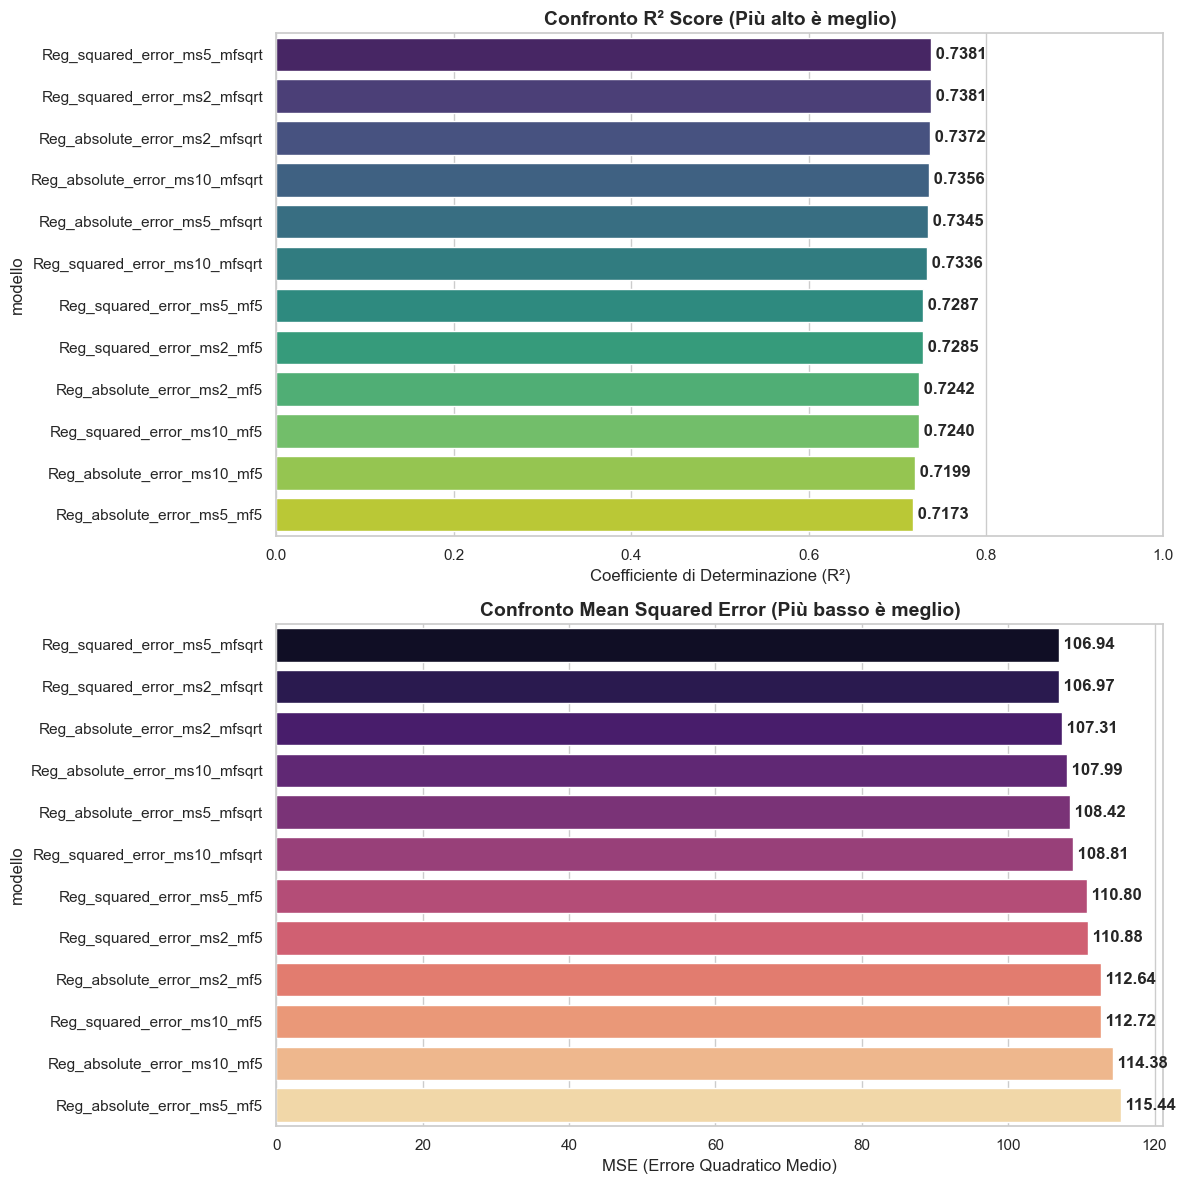

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualizza_confronto_regressori(df_risultati):
    """
    Crea un confronto visivo tra tutti i modelli di regressione basato su R2 e MSE.
    """
    # Impostiamo lo stile
    sns.set_theme(style="whitegrid")
    
    # Creiamo una figura con due grafici (uno per R2, uno per l'errore)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

    # --- 1. Grafico R^2 Score ---
    # Ordiniamo per R2 decrescente
    df_sorted_r2 = df_risultati.sort_values('R2_score', ascending=False)
    
    sns.barplot(
        x='R2_score', 
        y='modello', 
        data=df_sorted_r2, 
        hue='modello', 
        palette='viridis', 
        ax=ax1,
        legend=False
    )
    ax1.set_title('Confronto R² Score (Più alto è meglio)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Coefficiente di Determinazione (R²)')
    ax1.set_xlim(0, max(1, df_sorted_r2['R2_score'].max() + 0.1))
    
    # Aggiungiamo i valori numerici sulle barre
    for i, val in enumerate(df_sorted_r2['R2_score']):
        ax1.text(val, i, f' {val:.4f}', va='center', fontweight='bold')

    # --- 2. Grafico MSE (Errore Quadratico Medio) ---
    # Ordiniamo per MSE crescente (il migliore è quello con l'errore più basso)
    df_sorted_mse = df_risultati.sort_values('MSE', ascending=True)
    
    sns.barplot(
        x='MSE', 
        y='modello', 
        data=df_sorted_mse, 
        hue='modello', 
        palette='magma', 
        ax=ax2,
        legend=False
    )
    ax2.set_title('Confronto Mean Squared Error (Più basso è meglio)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('MSE (Errore Quadratico Medio)')

    # Aggiungiamo i valori numerici sulle barre
    for i, val in enumerate(df_sorted_mse['MSE']):
        ax2.text(val, i, f' {val:.2f}', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

# --- CHIAMATA ---
visualizza_confronto_regressori(df_risultati_reg)